# HousingData Analysis

### Business Understanding


#### Real Estate Investment and Development Planning

**Business Need:** Real estate investors and housing developers want to identify high-potential areas for new housing projects.

**Proposed Solution:** By analyzing crime rates (CRIM), accessibility (RAD, DIS, DMT), and environmental quality (LS, PR), developers can determine where to invest for maximum returns and minimal risks.

### Data Understanding

The dataset used is called **HousingData** with these attributes:
- PID - Property ID
- CRIM - per capita crime rate
- AC - Acreage Compound (Acres) proportion of compound/farmland 
- INDUS - proportion of non-retail business acres per town.
- LS - Lake-side residence (1 if residence bounds lake; 0 if residence is far from lake)
- PR- Pollution Rate (parts per 10 million)
- RM - average number of rooms per residence
- AGE - Age of property owner in years
- DIS - weighted distances to major employment centres
- RAD - index of accessibility to radial highways
- PTRATIO - pupil/teacher ratio by town
- DMT- Distance to Major Tourism (km)
- LSTAT - % lower status of the population
- MO - Number of minors per residence
- TAX - Property tax per year (dollars)


### Business Problem

##### Initial Questions

1. Which property locations by PID shows the lowest crime rates (CRIM) while still offering good accessibility to employment centres (DIS) and highways (RAD)?

2. How does proximity to tourism centres (DMT) and lake-side residence (LS) influence property attractiveness for investors?

3. What is the relationship between pollution levels (PR) and investment potential?

4. Which combination of factors (e.g., crime rate, accessibility for example DIS,DIM,INDUS,RAD, environmental quality for example LS) most strongly predicts investment potential?

##### Additional Questions

6. Are there specific towns or zones where future development risks are minimized due to favorable environmental and social indicators (low PR, balanced PTRATIO, low LSTAT)?

7. How can investors prioritize areas for development when balancing high accessibility (RAD, DIS) against potential social challenges (LSTAT, MO)?

### Data Preparation

In [2]:
# importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
#loading the dataset
df = pd.read_excel("C:/Users/DISCOVERY/Big_Data_Minning_&_Analystics/HousingData.xlsx")

In [4]:
#displaying the first 5 rows of the dataset
df.head()

,PID,CRIM,AC,INDUS,LS,PR,RM,AGE,DIS,RAD,PTRATIO,DMT,LSTAT,MO,TAX
0,101,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,15.3,396.90,4.98,2.0,296.0
1,102,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,17.8,396.90,9.14,2.0,242.0
2,103,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,17.8,292.40,4.03,3.0,242.0
3,104,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,18.7,394.63,2.94,0.0,222.0
4,105,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,18.7,396.90,5.33,0.0,222.0


In [5]:
df.shape

(506, 15)

In [6]:
#checking for missing values
df.isna().mean()

PID        0.000000
CRIM       0.003953
AC         0.000000
INDUS      0.000000
LS         0.003953
PR         0.005929
RM         0.007905
AGE        0.007905
DIS        0.005929
RAD        0.003953
PTRATIO    0.005929
DMT        0.007905
LSTAT      0.001976
MO         0.003953
TAX        0.001976
dtype: float64

In [10]:
# creation of a derived target variable called Investment_Potential to reflect the business need
# Defining columns to use 
positive_features = ["RAD", "RM"]         # higher = better
negative_features = ["CRIM", "PR", "DIS", "DMT", "LSTAT"]  # lower = better
binary_features   = ["LS"]                # already 0/1

# Normalize features (0–1 scale) 
for col in positive_features + negative_features:
    df[col + "_norm"] = (df[col] - df[col].min()) / (df[col].max() - df[col].min())

# Flip negative features (so that higher = better)
for col in negative_features:
    df[col + "_norm"] = 1 - df[col + "_norm"]

# Define weights
weights = {
    "CRIM_norm": 0.20,
    "PR_norm":   0.15,
    "DIS_norm":  0.15,
    "RAD_norm":  0.10,
    "DMT_norm":  0.10,
    "LS":        0.10,   # already normalized
    "LSTAT_norm":0.10,
    "RM_norm":   0.10
}

# Compute Investment Potential score 
df["Investment_Potential"] = sum(df[col] * w for col, w in weights.items())

# Optional: Categorize into High / Medium / Low 
def categorize(score):
    if score >= 0.75:
        return "High"
    elif score >= 0.5:
        return "Medium"
    else:
        return "Low"

df["Investment_Potential_Category"] = df["Investment_Potential"].apply(categorize)

# Preview results
print(df[["PID", "Investment_Potential", "Investment_Potential_Category"]].head())
print(df[["PID", "Investment_Potential", "Investment_Potential_Category"]].tail())

# Save back to excel
df.to_excel("dataset_with_investment_potential.xlsx", index=False)


   PID  Investment_Potential Investment_Potential_Category
0  101              0.561180                        Medium
1  102              0.560383                        Medium
2  103              0.615473                        Medium
3  104              0.581914                        Medium
4  105              0.577519                        Medium
     PID  Investment_Potential Investment_Potential_Category
501  602                   NaN                           Low
502  603              0.554845                        Medium
503  604              0.582341                        Medium
504  605              0.574276                        Medium
505  606                   NaN                           Low


In [11]:
df.head()

,PID,CRIM,AC,INDUS,LS,PR,RM,AGE,DIS,RAD,...,TAX,RAD_norm,RM_norm,CRIM_norm,PR_norm,DIS_norm,DMT_norm,LSTAT_norm,Investment_Potential,Investment_Potential_Category
0,101,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,...,296.0,0.000000,0.577505,1.000000,0.685185,0.730797,0.000000,0.910320,0.561180,Medium
1,102,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,...,242.0,0.043478,0.547998,0.999764,0.827160,0.651038,0.000000,0.795530,0.560383,Medium
2,103,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,...,242.0,0.043478,0.694386,0.999764,0.827160,0.651038,0.263503,0.936534,0.615473,Medium
3,104,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,...,222.0,0.086957,0.658555,0.999707,0.849794,0.551455,0.005724,0.966611,0.581914,Medium
4,105,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,...,222.0,0.086957,0.687105,0.999295,0.849794,0.551455,0.000000,0.900662,0.577519,Medium


In [12]:
df.shape

(506, 24)

#### Exploratory Data Analysis

In [13]:
#Descriptive stats
df.describe()

,PID,CRIM,AC,INDUS,LS,PR,RM,AGE,DIS,RAD,...,MO,TAX,RAD_norm,RM_norm,CRIM_norm,PR_norm,DIS_norm,DMT_norm,LSTAT_norm,Investment_Potential
count,506.000000,504.000000,506.000000,506.000000,504.000000,503.000000,502.000000,502.00000,503.000000,504.000000,...,504.000000,505.000000,504.000000,502.000000,504.000000,503.000000,503.000000,502.000000,505.000000,493.000000
mean,353.500000,3.604056,11.363636,11.136779,0.069444,0.554164,6.285307,68.53008,3.796207,9.492063,...,0.644841,407.726733,0.369220,0.521998,0.959562,0.651925,0.757513,0.230686,0.698562,0.592255
std,146.213884,8.609134,23.322453,6.860353,0.254461,0.115830,0.704098,28.13882,2.103234,8.676649,...,1.794307,168.312294,0.377246,0.134910,0.096765,0.238333,0.191257,0.360171,0.197243,0.058550
min,101.000000,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.90000,1.129600,1.000000,...,0.000000,187.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.407872
25%,227.250000,0.082155,0.000000,5.190000,0.000000,0.449000,5.885500,45.02500,2.100350,4.000000,...,0.000000,279.000000,0.130435,0.445392,0.958767,0.508230,0.633047,0.004797,0.579746,0.554851
50%,353.500000,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.50000,3.215700,5.000000,...,0.000000,330.000000,0.173913,0.507281,0.997188,0.685185,0.810301,0.025190,0.734823,0.584310
75%,479.750000,3.674808,12.500000,18.100000,0.000000,0.624000,6.623500,93.97500,5.164950,24.000000,...,0.000000,666.000000,1.000000,0.586798,0.999148,0.868313,0.911725,0.260546,0.856512,0.627318
max,606.000000,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.00000,12.126500,24.000000,...,19.000000,711.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.858096


In [60]:
#sanity check for Investment_Potential
print(df["Investment_Potential"].isna().sum()) # check for NaNs values


13


In [68]:
# Calculate the 10th percentile of CRIM (threshold for lowest 10%)
threshold = df["CRIM"].quantile(0.10)

# Filter properties with crime rates at or below this threshold
lowest_10_df = df[df["CRIM"] <= threshold]

# Show PID, crime rate, distance to employment centres (DIS), and highway accessibility (RAD)
result = lowest_10_df[["PID", "CRIM", "DIS", "RAD"]].sort_values(by="CRIM")

print("Top 10% lowest crime areas:")
print(result)


Top 10% lowest crime areas:
     PID     CRIM      DIS  RAD
0    101  0.00632   4.0900  1.0
284  385  0.00906   7.3073  1.0
285  386  0.01096   7.3073  1.0
341  442  0.01301   7.0379  1.0
55   156  0.01311   8.6966  5.0
54   155  0.01360   7.3197  3.0
195  296  0.01381   5.6484  4.0
57   158  0.01432   8.3248  5.0
194  295  0.01439   6.2196  1.0
348  449  0.01501   8.3440  4.0
283  384  0.01501   5.8850  1.0
256  357  0.01538   6.3361  3.0
353  454  0.01709  12.1265  5.0
200  301  0.01778   7.6534  3.0
347  448  0.01870   8.5353  4.0
64   165  0.01951   9.2229  3.0
286  387  0.01965   9.0892  1.0
204  305  0.02009   5.1180  4.0
56   157  0.02055   9.1876  2.0
202  303  0.02177   6.2700  2.0
193  294  0.02187   6.2196  1.0
342  443  0.02498   6.2669  1.0
343  444  0.02543   5.7321  5.0
2    103  0.02729   4.9671  2.0
1    102  0.02731   4.9671  2.0
39   140  0.02763   5.4011  3.0
93   194  0.02875   3.6659  4.0
349  450  0.02899   8.7921  1.0
5    106  0.02985   6.0622  3.0
337  438  0.

Question: Which property locations by PID shows the lowest crime rates (CRIM) while still offering good accessibility to employment centres (DIS) and highways (RAD)?

The results above show a 10% lowest crime rates (CRIM) property location by PID with good accessibility to employment centres (DIS) and highways (RAD)

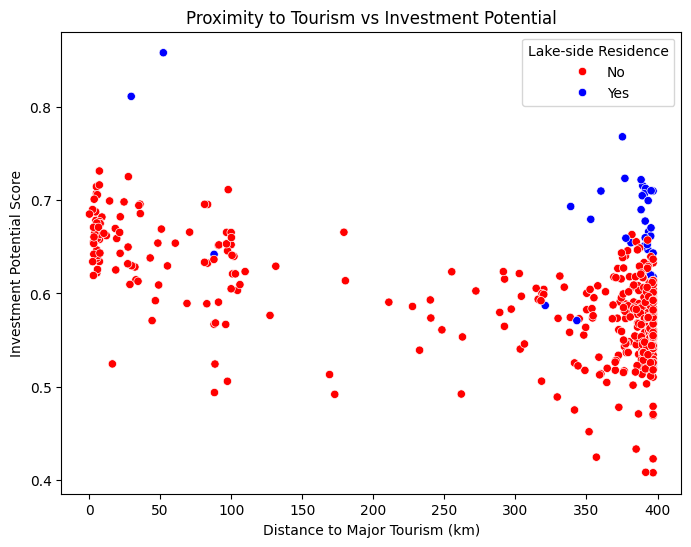

In [70]:
plt.figure(figsize=(8,6))

# Map LS values to descriptive labels directly
df["Lake_side"] = df["LS"].map({0: "No", 1: "Yes"})

sns.scatterplot(
    x="DMT", 
    y="Investment_Potential", 
    hue="Lake_side",   # use mapped labels
    data=df, 
    palette={"No": "red", "Yes": "blue"}
)

plt.title("Proximity to Tourism vs Investment Potential")
plt.xlabel("Distance to Major Tourism (km)")
plt.ylabel("Investment Potential Score")
plt.legend(title="Lake-side Residence")  # now legend matches colors properly
plt.show()

***Interpretations:***

The Blue points tend to be above the Red points thence attracting a High Investment Potential Score of over 0.6 as the DMT increases.

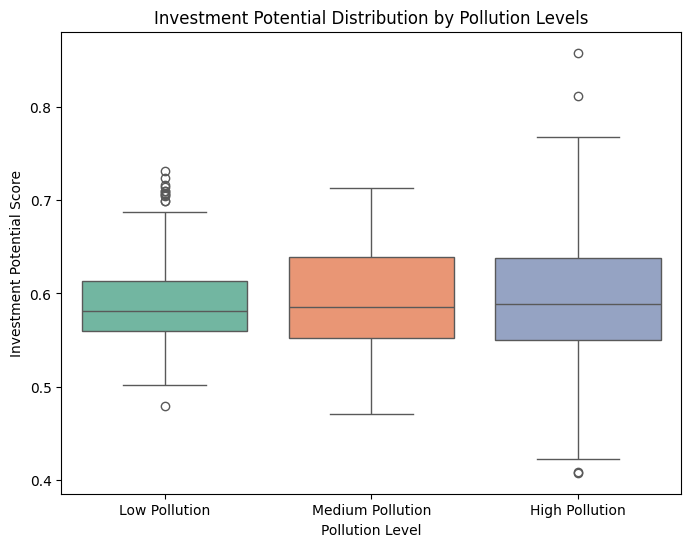

In [32]:
# Bin pollution into categories (adjust bins as needed)
df["PR_Category"] = pd.cut(
    df["PR"],
    bins=[0, df["PR"].quantile(0.33), df["PR"].quantile(0.66), df["PR"].max()],
    labels=["Low Pollution", "Medium Pollution", "High Pollution"]
)
        
# Boxplot of Investment Potential by Pollution Level
plt.figure(figsize=(8,6))
sns.boxplot(
    x="PR_Category",
    hue="PR_Category",
    y="Investment_Potential",
    data=df,
    palette="Set2",
    legend=False
)

plt.title("Investment Potential Distribution by Pollution Levels")
plt.xlabel("Pollution Level")
plt.ylabel("Investment Potential Score")
plt.show()

### Modeling

#### Step 1: Identifying features and target

***Target (y):*** Investment_Potential (we assume you have defined/calculated this earlier).

***Features (X):*** From the dataset:

Crime: CRIM

Accessibility: DIS, RAD, DMT, INDUS

Environmental quality: PR, LS

Socio-demographics: LSTAT, PTRATIO, AGE, MO

Property attributes: RM, AC, TAX

#### Step 2: Building a Predictive Model

In [45]:
#importing the necessary libraries
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import LabelEncoder

In [74]:
print(df.dtypes)

PID                                 int64
CRIM                              float64
AC                                float64
INDUS                             float64
LS                                float64
PR                                float64
RM                                float64
AGE                               float64
DIS                               float64
RAD                               float64
PTRATIO                           float64
DMT                               float64
LSTAT                             float64
MO                                float64
TAX                               float64
RAD_norm                          float64
RM_norm                           float64
CRIM_norm                         float64
PR_norm                           float64
DIS_norm                          float64
DMT_norm                          float64
LSTAT_norm                        float64
Investment_Potential              float64
Investment_Potential_Category     

In [86]:
df_encoded = df.copy()

In [87]:
#handling missing target values
df_encoded = df_encoded.dropna(subset=["Investment_Potential"])

In [88]:
# Identify all non-numeric columns
non_numeric_cols = df_encoded.select_dtypes(include=['object', 'category']).columns

In [89]:
# Encode them
for col in non_numeric_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])

In [90]:
# Define features and target
X = df_encoded.drop(columns=["PID", "Investment_Potential"])
#y = df_encoded.dropna(subset=["Investment_Potential"])
#y = df_encoded.fillna(subset=["Investment_Potential"].median())
#y = df_encoded["Investment_Potential"].fillna(df_encoded["Investment_Potential"].mean(), inplace=True)
# Fill the missing values using .loc
y = df_encoded.loc[:, "Investment_Potential"] = df_encoded["Investment_Potential"].fillna(df_encoded["Investment_Potential"].mean())

In [91]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [92]:
# Train model
model = RandomForestRegressor(n_estimators=200, random_state=42)
model.fit(X_train, y_train)


,n_estimators,200
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [95]:
# Evaluate
y_pred = model.predict(X_test)
print("R² Score:", r2_score(y_test, y_pred))
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
print("RMSE:", rmse)


R² Score: 0.8888552611268913
RMSE: 0.016375993972145245


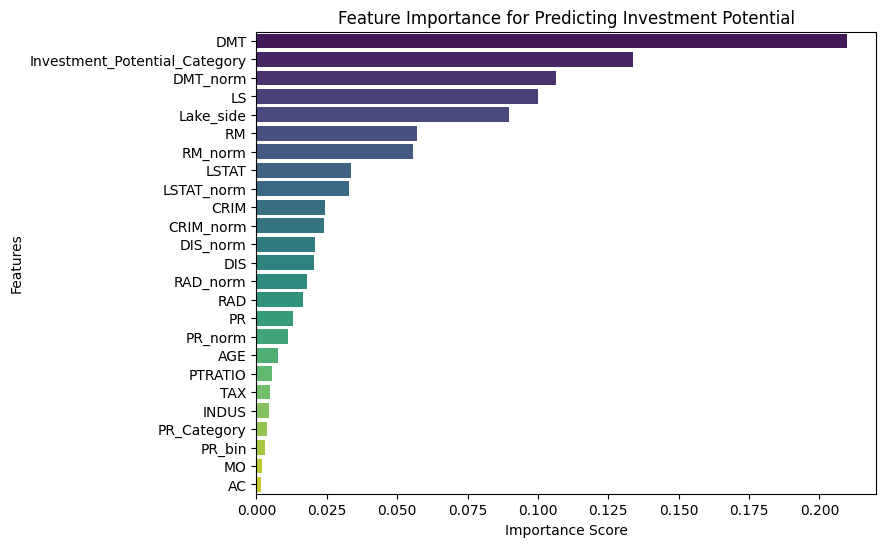

In [98]:
feat_importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(8,6))
sns.barplot(x=feat_importances, y=feat_importances.index, hue=feat_importances.index, palette="viridis", legend=False)
plt.title("Feature Importance for Predicting Investment Potential")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.show()

### Conclusions


#### Identify the Top Drivers

"The top three features that most influence a property's investment potential are DMT, Investment_Potential_Category, and LS."

Implications

"This suggests that the model primarily uses DMT to make its predictions. Therefore, when evaluating properties, these factor should be prioritized."

Identify Less Important Features

"Conversely, features like AC and MO had very little impact on the model's predictions, indicating they are not significant indicators of investment potential in this dataset."





